# J2 — analyse exploratoire et corrélations

Ce carnet est destiné à l’exploration graphique et statistique des corrélations dans les jeux de données FAO.

## 🎯 Objectifs
- Décrire les distributions des variables clés du dataset global.
- Identifier les pays et régions les plus affectés par la sous-nutrition.
- Mettre en évidence les disparités de disponibilité alimentaire.
- Conduire au moins deux analyses de corrélation avec tests statistiques.
- Interpréter les résultats en langage métier pour le commanditaire.

In [11]:
# 1. Imports & chargement du dataset global

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

sns.set(style="whitegrid")

DATA_DIR = Path("../data")
df = pd.read_csv(DATA_DIR / "global_fao_dataset.csv")
# création d'un alias simple pour la disponibilité calorique totale
if "Kcal_total_kcal_per_capita_per_day" in df.columns:
    df["Kcal_total"] = df["Kcal_total_kcal_per_capita_per_day"]


# 2.Visualisation du dataset

In [12]:
df.head()
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 10 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Code zone                           175 non-null    int64  
 1   Zone                                175 non-null    str    
 2   Kcal_veg                            175 non-null    float64
 3   Kcal_anim                           175 non-null    float64
 4   Kcal_total_kcal_per_capita_per_day  175 non-null    float64
 5   Population_milliers                 175 non-null    int64  
 6   Sous_alimentation_millions          99 non-null     float64
 7   Population_millions                 175 non-null    float64
 8   Taux_sous_nutrition_pct             99 non-null     float64
 9   Kcal_total                          175 non-null    float64
dtypes: float64(7), int64(2), str(1)
memory usage: 13.8 KB


,Code zone,Kcal_veg,Kcal_anim,Kcal_total_kcal_per_capita_per_day,Population_milliers,Sous_alimentation_millions,Population_millions,Taux_sous_nutrition_pct,Kcal_total
count,175.000000,175.000000,175.000000,175.000000,1.750000e+02,99.000000,175.000000,99.000000,175.000000
mean,126.720000,2292.377143,556.502857,2848.880000,4.807996e+04,8.821212,48.079960,17.882862,2848.880000
std,75.168519,292.712945,325.197321,437.742225,1.786327e+05,25.970667,178.632742,14.651752,437.742225
min,1.000000,1635.000000,63.000000,1879.000000,5.400000e+01,0.100000,0.054000,2.139953,1879.000000
25%,64.500000,2130.500000,254.000000,2532.500000,2.543500e+03,0.550000,2.543500,7.048096,2532.500000
50%,121.000000,2277.000000,531.000000,2833.000000,9.413000e+03,1.900000,9.413000,12.853470,2833.000000
75%,188.500000,2448.000000,812.500000,3184.000000,2.888150e+04,5.650000,28.881500,22.931784,3184.000000
max,351.000000,3188.000000,1497.000000,3770.000000,1.416667e+06,194.400000,1416.667000,60.658579,3770.000000


In [24]:
# 2.1 Rapport Sweetviz sur le dataset global
from pathlib import Path
from sweetviz import analyze

output_dir = Path("notebooks")
output_dir.mkdir(parents=True, exist_ok=True)

report_global = analyze(df, target_feat=None)
output_path = output_dir / "sweetviz_global_fao_dataset_report.html"
report_global.show_html(str(output_path))


Feature: Code zone                           |▉         | [  9%]   00:00 -> (00:01 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
Feature: Kcal_veg                            |██▋       | [ 27%]   00:03 -> (00:17 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal,

Report notebooks\sweetviz_global_fao_dataset_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


# 3. Analyse univariée des variables clés

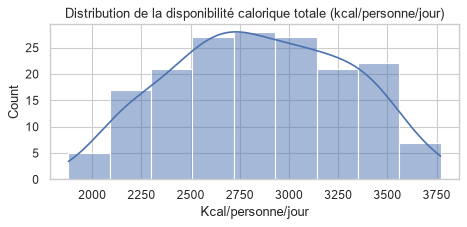

In [13]:
# 3.1 Disponibilité calorique totale

fig, ax = plt.subplots(figsize=(6,3), dpi=80)
sns.histplot(df["Kcal_total"].dropna(), kde=True, ax=ax)
ax.set_title("Distribution de la disponibilité calorique totale (kcal/personne/jour)")
ax.set_xlabel("Kcal/personne/jour")
plt.tight_layout()
plt.show()
plt.close(fig)


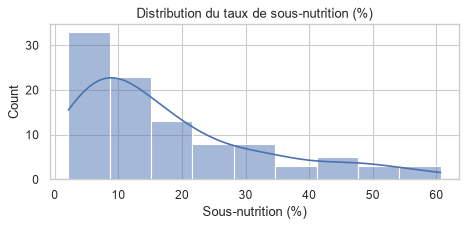

In [14]:
# 3.2 Taux de sous-nutrition

fig, ax = plt.subplots(figsize=(6,3), dpi=80)
sns.histplot(df["Taux_sous_nutrition_pct"].dropna(), kde=True, ax=ax)
ax.set_title("Distribution du taux de sous-nutrition (%)")
ax.set_xlabel("Sous-nutrition (%)")
plt.tight_layout()
plt.show()
plt.close(fig)


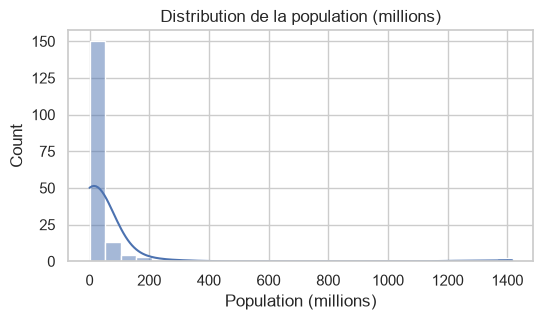

In [15]:
# 3.3 Population

plt.figure(figsize=(6,3))
sns.histplot(df["Population_millions"], kde=True)
plt.title("Distribution de la population (millions)")
plt.xlabel("Population (millions)")
plt.show()


4. Analyse bivariée & classements

# 4. Analyse bivariée & classements top/bottom


In [16]:
# 4.1 Top 10 pays les plus sous-alimentés

df.sort_values("Taux_sous_nutrition_pct", ascending=False).head(10)[
    ["Zone", "Taux_sous_nutrition_pct", "Kcal_total"]
]


,Zone,Taux_sous_nutrition_pct,Kcal_total
24,République centrafricaine,60.658579,1879.0
126,Zimbabwe,60.070671,2113.0
168,Zambie,55.024417,1924.0
61,Haïti,52.340797,2089.0
92,Madagascar,49.727372,2056.0
82,République populaire démocratique de Corée,49.005824,2093.0
30,Congo,47.212230,2206.0
156,Ouganda,46.834668,2126.0
167,Yémen,45.069038,2217.0
26,Tchad,43.664717,2109.0


In [17]:
# 4.2 Bottom 10 sous-nutrition

df.sort_values("Taux_sous_nutrition_pct", ascending=True).head(10)[
    ["Zone", "Taux_sous_nutrition_pct", "Kcal_total"]
]


,Zone,Taux_sous_nutrition_pct,Kcal_total
155,Émirats arabes unis,2.139953,3275.0
94,Malaisie,2.692062,2914.0
27,Chili,2.837684,2980.0
84,Koweït,2.968240,3499.0
158,Ukraine,3.315723,3138.0
0,Arménie,3.359086,2924.0
147,"Chine, Taiwan Province de",3.429061,2998.0
102,Maroc,3.635482,3402.0
138,Slovaquie,3.669725,2943.0
100,Mexique,3.842004,3068.0


In [18]:
# 4.3 Top 10 disponibilité calorique

df.sort_values("Kcal_total", ascending=False).head(10)[
    ["Zone", "Kcal_total", "Taux_sous_nutrition_pct"]
]


,Zone,Kcal_total,Taux_sous_nutrition_pct
8,Autriche,3770.0,NaN
169,Belgique,3737.0,NaN
154,Turquie,3708.0,NaN
159,États-Unis d'Amérique,3682.0,NaN
72,Israël,3610.0,NaN
71,Irlande,3602.0,NaN
73,Italie,3578.0,NaN
170,Luxembourg,3540.0,NaN
41,Égypte,3518.0,5.362192
52,Allemagne,3503.0,NaN


5. Cartographies

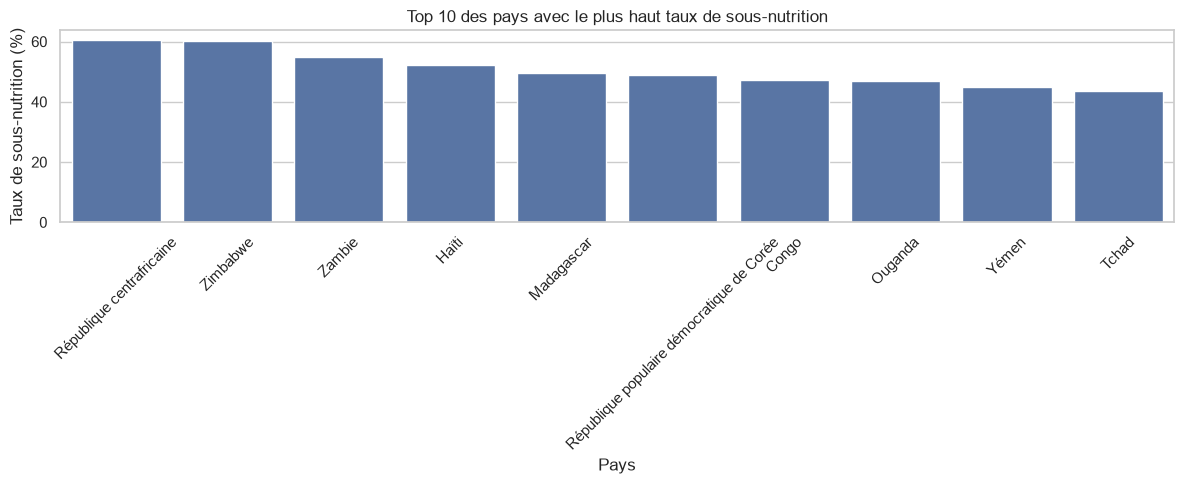

In [19]:
# 5. Disparités régionales 

# En ajoutant la colonne `Region` dans dataset global.

if "Region" in df.columns:
    plt.figure(figsize=(12,5))
    sns.boxplot(data=df, x="Region", y="Taux_sous_nutrition_pct")
    plt.xticks(rotation=45)
    plt.title("Sous-nutrition par région")
    plt.tight_layout()
    plt.show()
else:
    # Affiche les 10 pays avec le plus haut taux de sous-nutrition
    top10 = df.sort_values("Taux_sous_nutrition_pct", ascending=False).head(10)
    plt.figure(figsize=(12,5))
    sns.barplot(data=top10, x="Zone", y="Taux_sous_nutrition_pct")
    plt.xticks(rotation=45)
    plt.title("Top 10 des pays avec le plus haut taux de sous-nutrition")
    plt.xlabel("Pays")
    plt.ylabel("Taux de sous-nutrition (%)")
    plt.tight_layout()
    plt.show()
